# G5. Cross Comparison and Conclusions

**Authors:** Ivo Rambaldi and Tommaso Petrelli

**Course:** Ethics in Artificial Intelligence, University of Bologna, a.y. 2025-2026

## What this notebook does

It brings the four evaluation runs together and answers the questions the project set out with.
Nothing is retrained here; it reads what G3 and G4 wrote and compares along three axes: the
training data, real against each generator; the task, excellence against underperformance; and
the mitigation, none against each of the two techniques.

## The questions

1. How much accuracy is lost when the training data is synthetic.
2. How much of the fairness profile changes.
3. Are the two losses related, and is any generator acceptable on both.
4. Do the answers hold when the task is mirrored to the other tail.
5. Does fairness mitigation still work once the training data is synthetic.

The last two were added to the original proposal. Question 5 carries the most practical weight:
it asks whether the privacy motivated decision to use synthetic data quietly undermines the
fairness tooling applied afterwards.

## 1. Setup

In [15]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import pandas as pd

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")

from src.data.persistence import save_csv
from src.utils import check_prerequisites, get_logger, load_config, notebook_dirs

logger = get_logger("G5")
check_prerequisites()

cfg = load_config(PROJECT_ROOT / "config" / "config.yaml")
RESULTS_DIR, FIGURES_DIR = notebook_dirs(cfg, "g5")

TASKS = list(cfg["tasks"])
BASELINE = cfg["experiments"]["baseline_label"]
MITIGATION_ORDER = ["none"] + cfg["mitigation"]["methods"]

print(f"tasks      : {TASKS}")
print(f"mitigation : {MITIGATION_ORDER}")

Prerequisites: 16 satisfied, 0 missing, 0 mismatched.
tasks      : ['high_perf', 'low_perf']
mitigation : ['none', 'equalized_odds', 'prejudice_remover']


## 2. Reading the four runs

SMOTE appears under two names, because it had to be run once per task. They are the same
technique, so the underperformance variant is relabelled to line the two tasks up in one table.

In [16]:
def normalise_generator(name):
    """The two SMOTE outputs are one technique run twice, so they share a label here."""
    return "smote" if name == "smote_low_perf" else name


unmitigated = []
for task in TASKS:
    frame = pd.read_csv(cfg["paths"]["results_dir"] / "g3" / task / "metrics_matrix.csv")
    frame["task"] = task
    frame["mitigation"] = "none"
    unmitigated.append(frame)

unmitigated = pd.concat(unmitigated, ignore_index=True)
unmitigated["generator"] = unmitigated["method"].map(normalise_generator)
unmitigated["source"] = np.where(unmitigated["method"] == BASELINE, "real", "synthetic")

print(f"Unmitigated grids: {unmitigated.shape[0]} rows across {len(TASKS)} tasks")

Unmitigated grids: 30 rows across 2 tasks


In [17]:
mitigated = []
for task in TASKS:
    frame = pd.read_csv(cfg["paths"]["results_dir"] / "g4" / task / "mitigation_results.csv")
    frame["task"] = task
    mitigated.append(frame)

mitigated = pd.concat(mitigated, ignore_index=True)
mitigated = mitigated[mitigated["balanced_accuracy"].notna()]
mitigated["mitigation"] = mitigated["technique"]
mitigated["generator"] = mitigated["method"].map(normalise_generator)
mitigated["source"] = np.where(mitigated["method"] == BASELINE, "real", "synthetic")

# One mitigated fit exists per circumstance, so average over circumstances to get a single
# number per training set and classifier, comparable with the unmitigated grid.
shared = ["task", "mitigation", "generator", "source", "classifier"]
measures = ["balanced_accuracy", "f1_macro", "roc_auc", "mean_dpd", "mean_eod",
            "mean_di", "mean_odds_ratio"]
mitigated = mitigated.groupby(shared, as_index=False)[measures].mean()

combined = pd.concat(
    [unmitigated[shared + measures], mitigated[shared + measures]], ignore_index=True,
)
combined["mitigation"] = pd.Categorical(combined["mitigation"], MITIGATION_ORDER, ordered=True)

save_csv(combined, RESULTS_DIR / "combined_results.csv")
print(f"Combined: {combined.shape[0]} rows")

2026-08-02 15:50:05 | INFO     | src.data.persistence | Saved 70 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g5\combined_results.csv
Combined: 70 rows


## 3. Question 1: how much accuracy is lost

Balanced accuracy of each synthetic training set against the real baseline, on both tasks,
without any mitigation.

In [18]:
no_mitigation = combined[combined["mitigation"] == "none"]

utility = (
    no_mitigation.groupby(["task", "generator"], observed=True)["balanced_accuracy"]
    .mean().unstack("task").round(4)
)
real_row = utility.loc[BASELINE]
utility_loss = (utility - real_row).drop(index=BASELINE).round(4)

print("Mean balanced accuracy, averaged across the three classifiers:")
print(utility.to_string())
print("\nChange from the real baseline, negative means worse:")
print(utility_loss.to_string())

# Balanced accuracy starts at 0.5 for a coin flip, so the real baseline only holds a narrow
# band of usable signal above chance. Expressing the loss as a share of that band is what says
# how much of the signal a generator actually destroyed.
headroom = real_row - 0.5
share_lost = (-utility_loss / headroom).round(3)
print(f"\nSignal available above chance: {headroom.round(4).to_dict()}")
print("Share of it lost, 1.0 means the generator gave up everything the real data had:")
print(share_lost.to_string())

save_csv(utility.reset_index(), RESULTS_DIR / "utility_by_task.csv")

Mean balanced accuracy, averaged across the three classifiers:
task             high_perf  low_perf
generator                           
ctgan               0.5913    0.5750
gaussian_copula     0.4823    0.5552
real                0.6117    0.6059
smote               0.5718    0.5481
tvae                0.5966    0.6040

Change from the real baseline, negative means worse:
task             high_perf  low_perf
generator                           
ctgan              -0.0204   -0.0309
gaussian_copula    -0.1294   -0.0507
smote              -0.0399   -0.0578
tvae               -0.0151   -0.0019

Signal available above chance: {'high_perf': 0.1117, 'low_perf': 0.1059}
Share of it lost, 1.0 means the generator gave up everything the real data had:
task             high_perf  low_perf
generator                           
ctgan                0.183     0.292
gaussian_copula      1.158     0.479
smote                0.357     0.546
tvae                 0.135     0.018
2026-08-02 15:50:05 | INFO

2026-08-02 15:50:05 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g5\utility_by_task.png


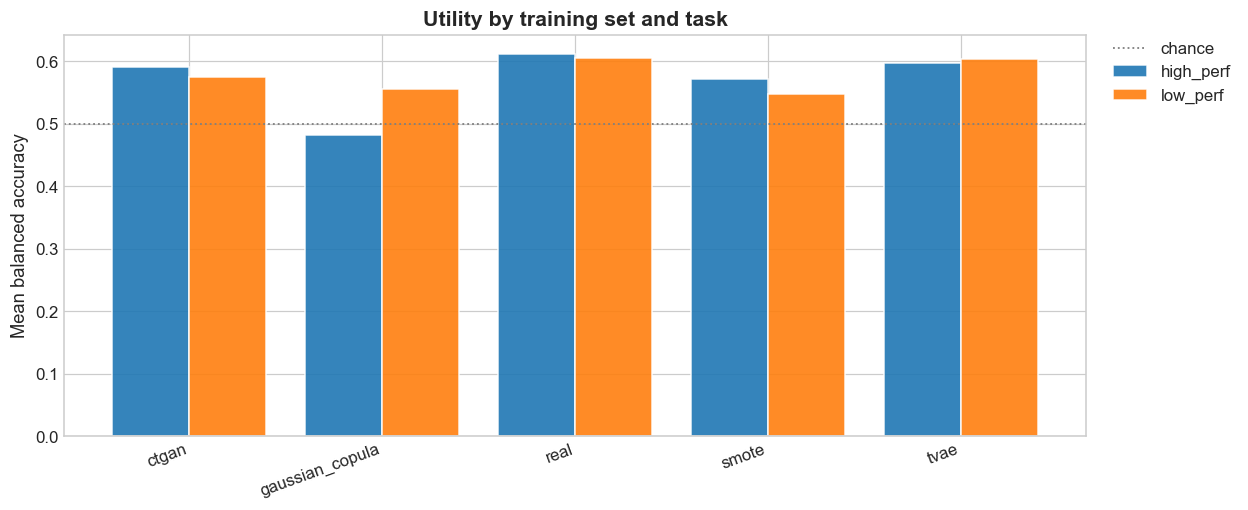

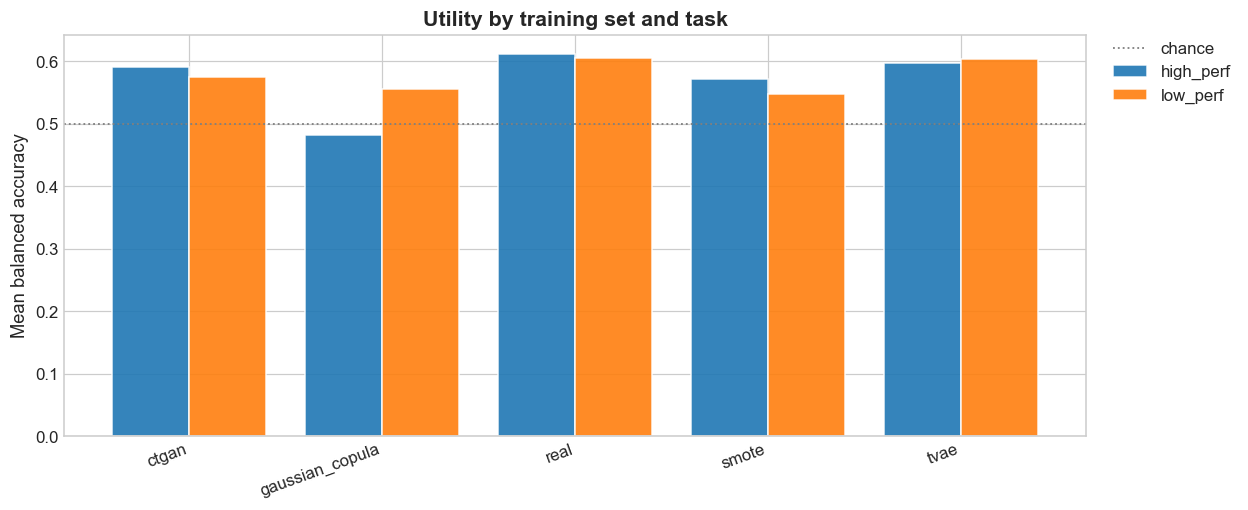

In [19]:
from src.utils.plotting import plot_grouped_bars

plot_grouped_bars(utility, "Mean balanced accuracy",
                  "Utility by training set and task",
                  FIGURES_DIR, "utility_by_task",
                  reference_line=0.5, reference_label="chance")

**Observation.** Every generator costs accuracy on both tails, so some loss is unavoidable, and
the size of it separates the methods sharply.

The share lost is the number to read, not the raw loss. Balanced accuracy cannot fall below 0.5
without the model becoming anti correlated with the truth, so the real baseline holds only about
0.11 of usable signal above chance, and a change that looks small in accuracy points is a large
fraction of everything there was to lose. A share above 1 means the generator pushed the model
past chance, and its fairness numbers must then be read as meaningless rather than as good.

No generator loses the same share on both tails, so a study measuring one tail alone would have
misstated the size of the loss on the other. The ordering of the generators is a separate
question, taken up in section 6.

## 4. Question 2: how much fairness changes

Mean DPD across the circumstances, and the odds ratio that Marrero et al. lead with. For DPD
lower is closer to parity. For the odds ratio 1 is parity, and below 1 means the model finds the
advantaged students more reliably than the disadvantaged ones.

In [20]:
fairness = (
    no_mitigation.groupby(["task", "generator"], observed=True)[["mean_dpd", "mean_odds_ratio"]]
    .mean().round(4)
)
print(fairness.unstack("task").to_string())
save_csv(fairness.reset_index(), RESULTS_DIR / "fairness_by_task.csv")

                 mean_dpd          mean_odds_ratio         
task            high_perf low_perf       high_perf low_perf
generator                                                  
ctgan              0.3511   0.2237          0.4665   3.0837
gaussian_copula    0.0729   0.1284          1.4054   1.7566
real               0.2526   0.2129          0.6033   2.9555
smote              0.1493   0.0908          0.5787   2.4084
tvae               0.3052   0.2726          0.4651   2.9732
2026-08-02 15:50:06 | INFO     | src.data.persistence | Saved 10 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g5\fairness_by_task.csv


2026-08-02 15:50:07 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g5\fairness_by_task.png


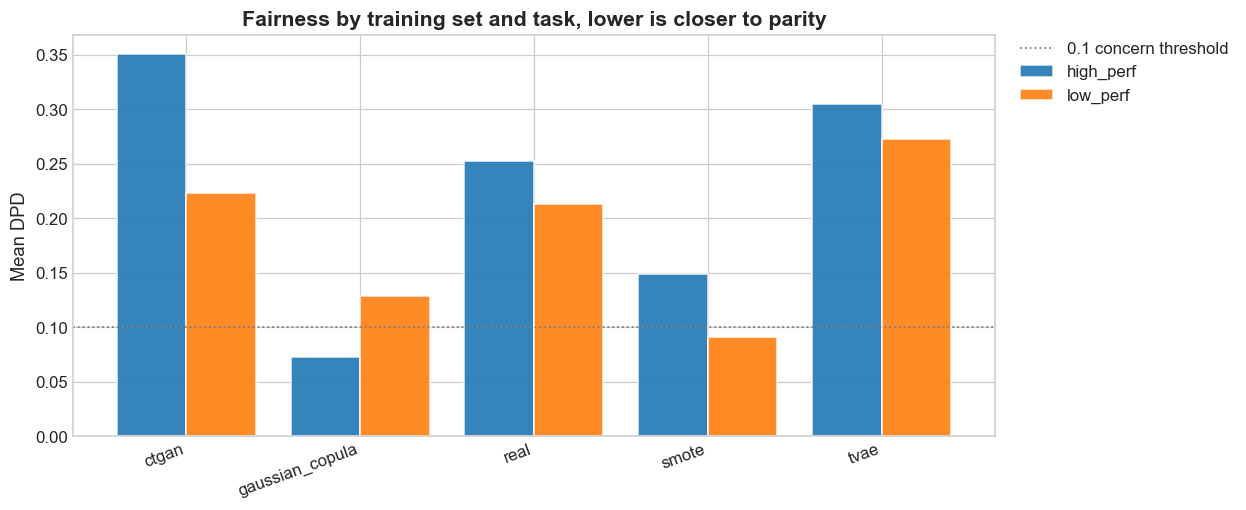

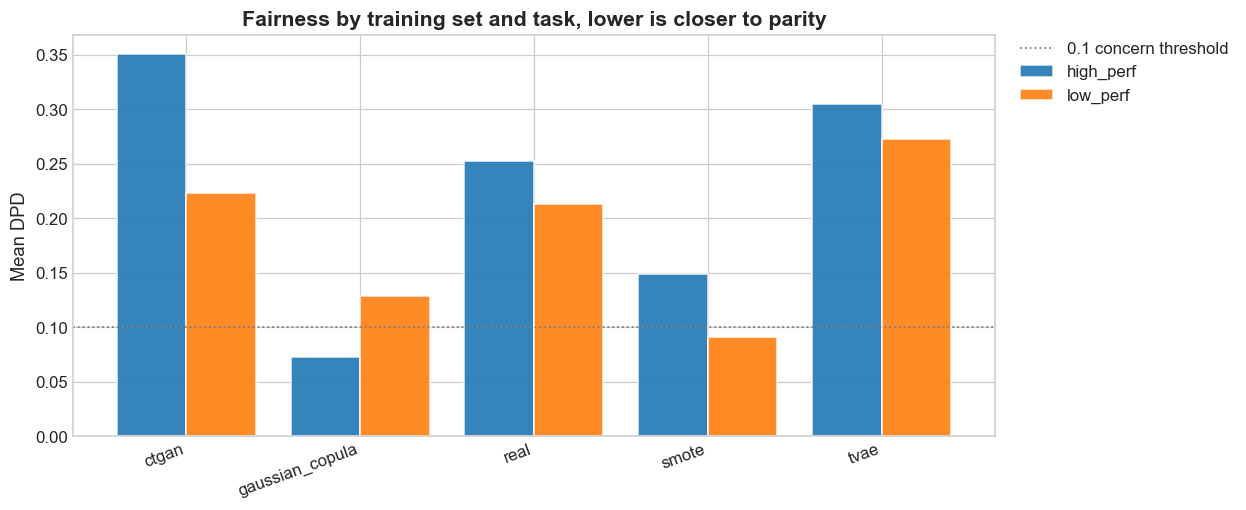

In [21]:
dpd = no_mitigation.groupby(["task", "generator"], observed=True)["mean_dpd"].mean().unstack("task")
plot_grouped_bars(dpd, "Mean DPD",
                  "Fairness by training set and task, lower is closer to parity",
                  FIGURES_DIR, "fairness_by_task",
                  reference_line=cfg["fairness"]["dpd_threshold"],
                  reference_label="0.1 concern threshold")

**Observation.** The real baseline is far from parity on both tails, DPD 0.2526 on excellence and
0.2129 on underperformance against a 0.1 concern threshold, and G1 found the same gradient in the
raw scores before any model existed. What follows therefore measures how generation interacts with
inequality already in the data.

Two of the four generators appear to improve on that, the copula and SMOTE, both to inside the
threshold the real data fails. Neither is a fairness gain: parity arrives together with the model
losing its ability to discriminate. The other two land further from parity than the real baseline
on both tails. Section 5 measures how general that pairing is.

## 5. Question 3: are the two losses related

Each point is one training set and classifier. The region a practitioner would want is high
accuracy with low DPD, towards the bottom right.

2026-08-02 15:50:09 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g5\utility_vs_fairness.png


WindowsPath('C:/Users/tomma/Desktop/petrellirambaldi2526/results/figures/g5/utility_vs_fairness.png')

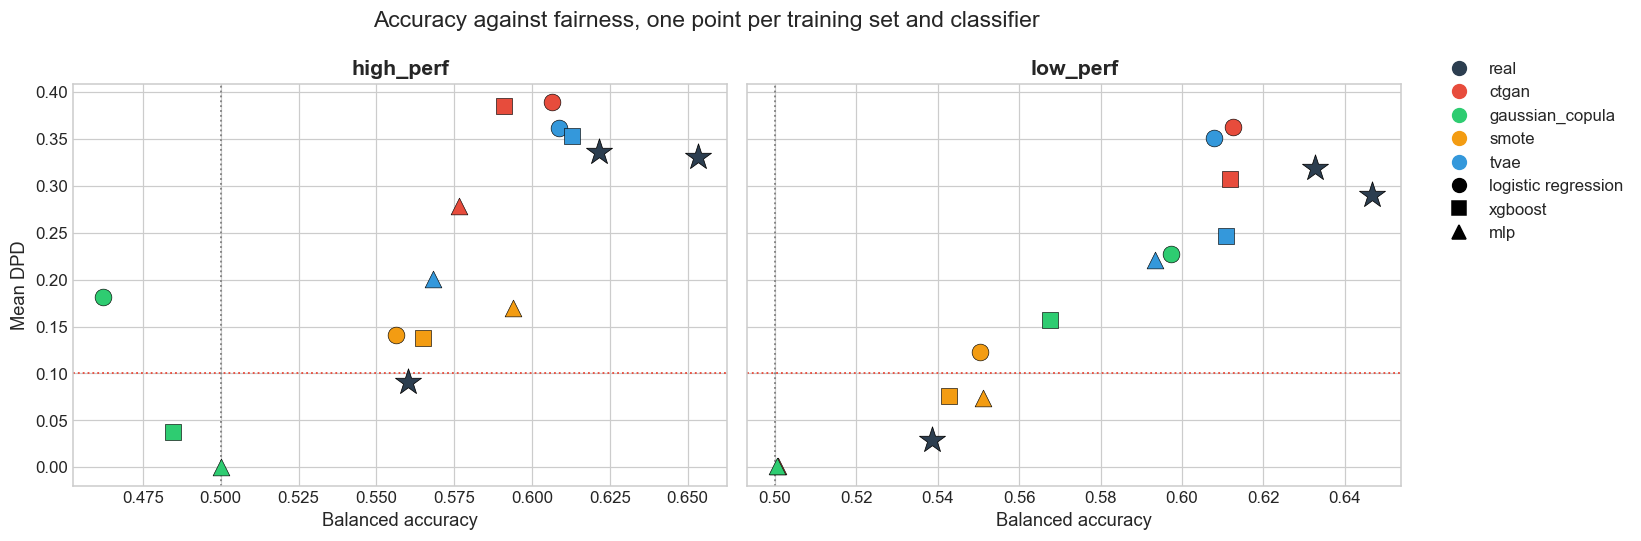

In [22]:
synthetic_only = no_mitigation[no_mitigation["source"] == "synthetic"]

fig, axes = plt.subplots(1, len(TASKS), figsize=(13, 5), sharey=True)
markers = {"logistic_regression": "o", "xgboost": "s", "mlp": "^"}

from src.utils.plotting import METHOD_COLORS, GREY, save_figure

for ax, task in zip(np.atleast_1d(axes), TASKS):
    subset = synthetic_only[synthetic_only["task"] == task]
    real_point = no_mitigation[(no_mitigation["task"] == task) & (no_mitigation["source"] == "real")]
    ax.scatter(real_point["balanced_accuracy"], real_point["mean_dpd"],
               marker="*", s=320, color=METHOD_COLORS.get("real", GREY), edgecolors="black",
               linewidths=0.5, zorder=4, label="real")
    for _, row in subset.iterrows():
        ax.scatter(row["balanced_accuracy"], row["mean_dpd"],
                   color=METHOD_COLORS.get(row["generator"], GREY),
                   marker=markers.get(row["classifier"], "o"),
                   s=120, edgecolors="black", linewidths=0.4, zorder=3)
    ax.axhline(cfg["fairness"]["dpd_threshold"], color="#e74c3c", ls=":", lw=1.2)
    ax.axvline(0.5, color="grey", ls=":", lw=1.2)
    ax.set_title(task)
    ax.set_xlabel("Balanced accuracy")

np.atleast_1d(axes)[0].set_ylabel("Mean DPD")

handles = [plt.Line2D([], [], marker="o", ls="", markersize=9, color=METHOD_COLORS.get(g, GREY), label=g)
           for g in ["real"] + sorted(synthetic_only["generator"].unique())]
handles += [plt.Line2D([], [], marker=m, ls="", markersize=9, color="black", label=c.replace("_", " "))
            for c, m in markers.items()]
fig.legend(handles=handles, bbox_to_anchor=(1.01, 0.9), loc="upper left", borderaxespad=0)
fig.suptitle("Accuracy against fairness, one point per training set and classifier")
fig.tight_layout()
save_figure(fig, "utility_vs_fairness", FIGURES_DIR)

In [23]:
# The two changes, paired per training set and classifier, against the matching real row.
paired = []
for task in TASKS:
    subset = no_mitigation[no_mitigation["task"] == task]
    reference = subset[subset["source"] == "real"].set_index("classifier")
    synthetic = subset[subset["source"] == "synthetic"].copy()
    synthetic["accuracy change"] = (
        synthetic["balanced_accuracy"] - synthetic["classifier"].map(reference["balanced_accuracy"])
    )
    synthetic["dpd change"] = (
        synthetic["mean_dpd"] - synthetic["classifier"].map(reference["mean_dpd"])
    )
    paired.append(synthetic[["task", "generator", "classifier", "accuracy change", "dpd change"]])

paired = pd.concat(paired, ignore_index=True)
correlation = paired["accuracy change"].corr(paired["dpd change"])
both_fell = int(((paired["accuracy change"] < 0) & (paired["dpd change"] < 0)).sum())

print(f"Runs compared: {len(paired)}")
print(f"Correlation between the accuracy change and the DPD change: {correlation:.3f}")
print(f"Runs that lost accuracy and lowered DPD together: {both_fell} of {len(paired)}")

Runs compared: 24
Correlation between the accuracy change and the DPD change: 0.879
Runs that lost accuracy and lowered DPD together: 12 of 24


**Observation.** The correlation is 0.879 across the 24 synthetic runs, and half of them, 12 of 24,
lost accuracy and lowered DPD together. Utility loss and fairness gain are not two axes to trade
off; on this data they are largely one effect measured twice.

A model pushed towards chance predicts the positive class at more similar rates in every group,
and demographic parity rewards exactly that. The copula is the clearest case: of the four generators it has the
best mean DPD and is the only one whose mean accuracy falls below chance. A practitioner who read that as a
fairness gain would have read a broken model as a fair one, and nothing in a standard fairness
report would catch it. Hence the rule used throughout: never report a parity metric without the
accuracy beside it.

## 6. Question 4: does the picture hold on the other tail

The two tasks use the same students, the same features and the same generators. Only the label
changes, from the top quarter to the bottom quarter, so a ranking that survives the switch is a
property of the generator and one that does not is a property of the task.

In [24]:
ranking = (
    no_mitigation[no_mitigation["source"] == "synthetic"]
    .groupby(["task", "generator"], observed=True)["balanced_accuracy"].mean()
    .unstack("task")
)
ranking["rank " + TASKS[0]] = ranking[TASKS[0]].rank(ascending=False).astype(int)
ranking["rank " + TASKS[1]] = ranking[TASKS[1]].rank(ascending=False).astype(int)
print("Utility ranking of the generators on each task, 1 is best:")
print(ranking.round(4).to_string())

correlation = ranking[TASKS[0]].corr(ranking[TASKS[1]], method="spearman")
print(f"\nRank correlation between the two tasks: {correlation:.2f}")

Utility ranking of the generators on each task, 1 is best:
task             high_perf  low_perf  rank high_perf  rank low_perf
generator                                                          
ctgan               0.5913    0.5750               2              2
gaussian_copula     0.4823    0.5552               4              3
smote               0.5718    0.5481               3              4
tvae                0.5966    0.6040               1              1

Rank correlation between the two tasks: 0.80


**Observation.** The rank correlation between the two tasks is 0.80, so the order is largely
preserved: TVAE is first on both tails and CTGAN second on both.

Read the accuracy columns beside the ranks before concluding from them. TVAE and CTGAN are
separated by under a hundredth on excellence, and the copula and SMOTE by under a hundredth on
underperformance, gaps too small to call an ordering. What does depend on the task is the size of
a failure rather than its rank: the copula is far below everything else on excellence, under
chance, and merely mid table on underperformance. A single task's experiment would misstate how
badly it can fail.

## 7. Question 5: does mitigation still work on synthetic data

G4 measured, for every circumstance, how much of its gap each technique removed, separately for
models trained on real and on synthetic data. If the two are close, fairness tooling transfers.
If not, the privacy motivated switch to synthetic data has weakened the repair applied
afterwards.

In [25]:
comparisons = []
for task in TASKS:
    frame = pd.read_csv(cfg["paths"]["results_dir"] / "g4" / task / "mitigation_comparison.csv")
    frame["task"] = task
    comparisons.append(frame)

comparisons = pd.concat(comparisons, ignore_index=True)
comparisons["source"] = np.where(comparisons["method"] == BASELINE, "real", "synthetic")

effectiveness = (
    comparisons.groupby(["task", "technique", "source"])[
        ["dpd_before", "dpd_after", "dpd_improvement", "eod_improvement",
         "di_improvement", "balanced_accuracy"]
    ].mean()
)
effectiveness["share_closed"] = (
    effectiveness["dpd_improvement"] / effectiveness["dpd_before"]
)
print("Mitigation effectiveness, positive improvement means fairer:")
print(effectiveness.round(4).to_string())
save_csv(effectiveness.reset_index(), RESULTS_DIR / "mitigation_effectiveness.csv")

Mitigation effectiveness, positive improvement means fairer:
                                       dpd_before  dpd_after  dpd_improvement  eod_improvement  di_improvement  balanced_accuracy  share_closed
task      technique         source                                                                                                             
high_perf equalized_odds    real           0.2526     0.0347           0.2180           0.2384          0.4454             0.6182        0.8628
                            synthetic      0.2196     0.1101           0.1095           0.1221          0.2813             0.5494        0.4988
          prejudice_remover real           0.2526     0.0554           0.1973           0.1781         -0.1631             0.5324        0.7809
                            synthetic      0.2196     0.1393           0.0802           0.0740         -0.0509             0.5473        0.3654
low_perf  equalized_odds    real           0.2129     0.0254           0.18

Share of the gap each source closes, and the difference between them:
                            dpd_before           dpd_after           share_closed           shortfall
source                            real synthetic      real synthetic         real synthetic          
task      technique                                                                                  
high_perf equalized_odds        0.2526    0.2196    0.0347    0.1101       0.8628    0.4988    0.3640
          prejudice_remover     0.2526    0.2196    0.0554    0.1393       0.7809    0.3654    0.4154
low_perf  equalized_odds        0.2129    0.1789    0.0254    0.1123       0.8809    0.3723    0.5086
          prejudice_remover     0.2129    0.1789    0.0190    0.0929       0.9108    0.4803    0.4305
2026-08-02 15:50:10 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g5\mitigation_real_vs_synthetic.png


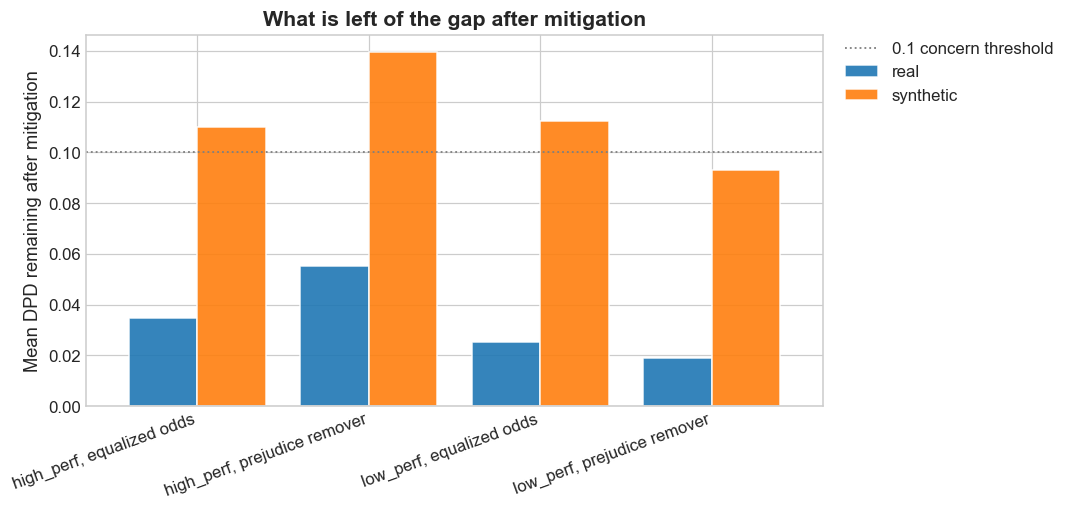

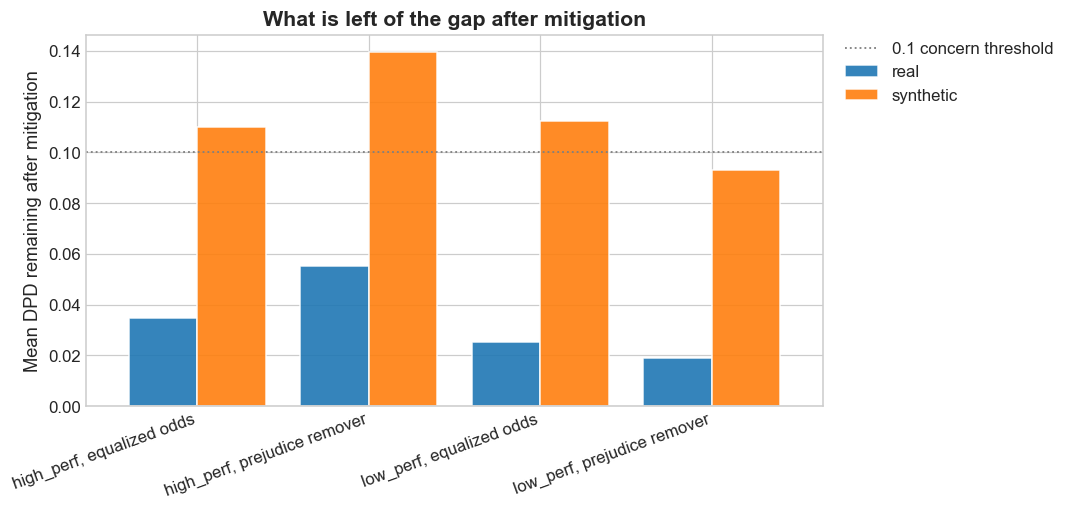

In [26]:
gap = effectiveness[["dpd_before", "dpd_after", "share_closed"]].unstack("source")
gap["shortfall"] = (
    gap[("share_closed", "real")] - gap[("share_closed", "synthetic")]
)
print("Share of the gap each source closes, and the difference between them:")
print(gap.round(4).to_string())

remaining = effectiveness["dpd_after"].unstack("source")
remaining.index = [f"{task}, {technique.replace('_', ' ')}" for task, technique in remaining.index]
plot_grouped_bars(remaining,
                  "Mean DPD remaining after mitigation",
                  "What is left of the gap after mitigation",
                  FIGURES_DIR, "mitigation_real_vs_synthetic",
                  reference_line=cfg["fairness"]["dpd_threshold"],
                  reference_label="0.1 concern threshold")

**Observation.** The headline result. The two techniques remove 78 to 91 per cent of the targeted
gap on real training data and 37 to 50 per cent on synthetic, on both tasks and with both
techniques.

The objection is that the synthetic models start with a smaller gap. The share closed divides that
out, and `dpd_after`, the gap a student is left with, does not depend on where either source
started: the synthetic models end two to five times further from parity despite starting closer.
Section 5 showed weaker models look fairer, so that artefact pushes against this result rather
than producing it.

## 8. Direction of the bias across the two tails

The odds ratio is the recall of the unprivileged group over the recall of the privileged one, so
unlike the other metrics it has a direction. Below 1 the model finds advantaged students more
reliably, above 1 disadvantaged ones. This counts how general that direction is, across the
individual circumstances of the real baseline rather than across their average.

In [27]:
sides = []
for task in TASKS:
    directory = cfg["paths"]["results_dir"] / "g3" / task / "per_attribute_fairness"
    for classifier in ["logistic_regression", "xgboost", "mlp"]:
        detail = pd.read_csv(directory / f"fairness_{BASELINE}_{classifier}.csv")
        ratios = detail["odds_ratio"].dropna()
        sides.append({
            "task": task,
            "classifier": classifier,
            "circumstances measured": len(ratios),
            "below 1": int((ratios < 1).sum()),
            "above 1": int((ratios > 1).sum()),
            "median": round(ratios.median(), 3),
        })

print("Direction of the odds ratio per circumstance, real training data:")
print(pd.DataFrame(sides).to_string(index=False))

Direction of the odds ratio per circumstance, real training data:
     task          classifier  circumstances measured  below 1  above 1  median
high_perf logistic_regression                      13       13        0   0.652
high_perf             xgboost                      13       13        0   0.700
high_perf                 mlp                      13       13        0   0.434
 low_perf logistic_regression                      13        0       13   1.688
 low_perf             xgboost                      13        0       13   1.769
 low_perf                 mlp                      13        2       11   2.028


**Observation.** The split is total. On the excellence task all 13 circumstances come out below 1
for all three classifiers, 39 of 39, and on underperformance 37 of 39 come out above it. The
direction belongs to the tail, not to a circumstance and not to a classifier.

The model is therefore not simply less accurate for disadvantaged students. It is less willing to
place them in whichever class it has been asked to detect.

Used to award selective places, that compounds an advantage those students already had. Used to
allocate remedial support, the identical statistic describes who is offered help. Neither
direction is automatically wrong, and an audit reporting the metric without naming the decision
cannot tell the two cases apart.

## 9. Summary

In [28]:
print("Real baseline and the cost of each synthetic generator")
for task in TASKS:
    subset = no_mitigation[no_mitigation["task"] == task]
    real_ba = subset.loc[subset["source"] == "real", "balanced_accuracy"].mean()
    real_dpd = subset.loc[subset["source"] == "real", "mean_dpd"].mean()
    print(f"\n{task}: real balanced accuracy {real_ba:.4f}, mean DPD {real_dpd:.4f}")

    per_generator = (
        subset[subset["source"] == "synthetic"]
        .groupby("generator", observed=True)[["balanced_accuracy", "mean_dpd"]].mean()
        .sort_values("balanced_accuracy", ascending=False)
    )
    for generator, row in per_generator.iterrows():
        print(f"  {generator:<16} accuracy {row['balanced_accuracy']:.4f} "
              f"({row['balanced_accuracy'] - real_ba:+.4f})    "
              f"DPD {row['mean_dpd']:.4f} ({row['mean_dpd'] - real_dpd:+.4f})")

Real baseline and the cost of each synthetic generator

high_perf: real balanced accuracy 0.6117, mean DPD 0.2526
  tvae             accuracy 0.5966 (-0.0151)    DPD 0.3052 (+0.0525)
  ctgan            accuracy 0.5913 (-0.0204)    DPD 0.3511 (+0.0984)
  smote            accuracy 0.5718 (-0.0399)    DPD 0.1493 (-0.1033)
  gaussian_copula  accuracy 0.4823 (-0.1294)    DPD 0.0729 (-0.1798)

low_perf: real balanced accuracy 0.6059, mean DPD 0.2129
  tvae             accuracy 0.6040 (-0.0019)    DPD 0.2726 (+0.0597)
  ctgan            accuracy 0.5750 (-0.0309)    DPD 0.2237 (+0.0108)
  gaussian_copula  accuracy 0.5552 (-0.0508)    DPD 0.1284 (-0.0845)
  smote            accuracy 0.5481 (-0.0578)    DPD 0.0908 (-0.1221)


### 9.1 The five questions

**Q1, how much accuracy is lost.** Always some, and how much depends entirely on the generator.
The real baseline holds only about 0.11 of balanced accuracy above chance, and the generators give
up between 2 per cent of that band and more than all of it.

**Q2, how much fairness changes.** It changes on every generator, but almost never in a way worth
having. Two of the four move inside the 0.1 threshold that the real baseline fails, and the other
two land further from parity than the real baseline does.

**Q3, are the two related.** Yes, and more tightly than a trade off. The correlation between the
accuracy change and the DPD change is 0.879 across 24 runs, because parity metrics reward a model
that has stopped discriminating.

**Q4, does the picture hold on the other tail.** For the direction of the bias, no, and
emphatically so: 39 of 39 circumstance and classifier combinations favour the advantaged group on
excellence, and 37 of 39 favour the disadvantaged group on underperformance. For the ranking of
the generators, largely yes, at a rank correlation of 0.80, but the size of a failure is task
dependent: the copula falls below chance on excellence and is unremarkable on underperformance.

**Q5, does mitigation still work on synthetic data.** Only about half as well, and the result
survives the objection that the synthetic models started closer to parity.

Replacing real training data with synthetic data does not merely cost accuracy. It weakens the
fairness tooling applied afterwards, while making the standard fairness metrics look better.

## 10. Limitations

Carried forward from the earlier notebooks and stated here so the conclusions above are read with
them in mind.

- The SMOTE rows are not a substitution. An oversampler appends to the table it was given,
  so two thirds of a SMOTE file is the real training set copied unmodified and the
  synthetic third is single class. Its classifiers see every real record, it offers no
  privacy protection, and its numbers bound what a genuine substitute could achieve
  rather than measuring one.
- The circumstances are heavily unanswered, up to most of the test set for country of birth.
  Every fairness number for those attributes is computed on the students who did answer, and
  those students are not a random sample.
- `mean_odds_ratio` is a ratio of two recalls, so it is estimated less precisely when a group
  holds few positive cases. The support floor never binds here, since the smallest group holds 59
  positive cases against a floor of ten, and the entries recorded as undefined all come from a
  zero denominator. A group the model rarely detects still gives a large ratio, so read which side
  of 1 a value falls on, and medians rather than means.
- A row flagged `degenerate_predictions` predicted a single class for the whole test set. Its DPD
  of zero is arithmetic, not fairness. The flag is literal, so a model that predicts one class for
  all but a handful of students escapes it while behaving the same way; the copula and CTGAN MLP rows on
  underperformance are such cases. Read the flag together with the balanced accuracy column.
- The MLP is the least stable of the three classifiers and the one that collapses to a single
  class when the training data is poor. Conclusions resting on the MLP alone are weaker than
  those visible in all three.
- The feature set was selected by mutual information against the excellence target and then used
  for both tasks. Holding it fixed is what makes the two comparable, but the selection itself was
  made with one of them in view.
- One split and one draw per generator, and no confidence intervals, so small gaps between
  generators should not be over read. Every stage is deterministic under the seed in
  `config.yaml`, which makes these results repeatable, but repeatability says nothing about how
  much a generator would vary under a different seed.